<a href="https://colab.research.google.com/github/danishalif04/Lab-8/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data successfully loaded and cleaned! Dimensions: (734, 31)
--------------------------------------------------

--- QUESTION 1 OUTPUT ---


,Player,Tm,PTS
0,Luka Dončić,LAL,33.5



--- QUESTION 2 OUTPUT ---


,Player,Pos,PTS
0,Luka Dončić,PG,33.5



--- QUESTION 3 OUTPUT ---


,Player,G,PTS
0,Luka Dončić,64.0,33.5



--- QUESTION 4 OUTPUT ---


,Player,Tm,AST
7,Nikola Jokić,DEN,10.7



--- QUESTION 5 OUTPUT ---
Total number of players scoring > 25 PTS: 17

--- QUESTION 6 OUTPUT ---


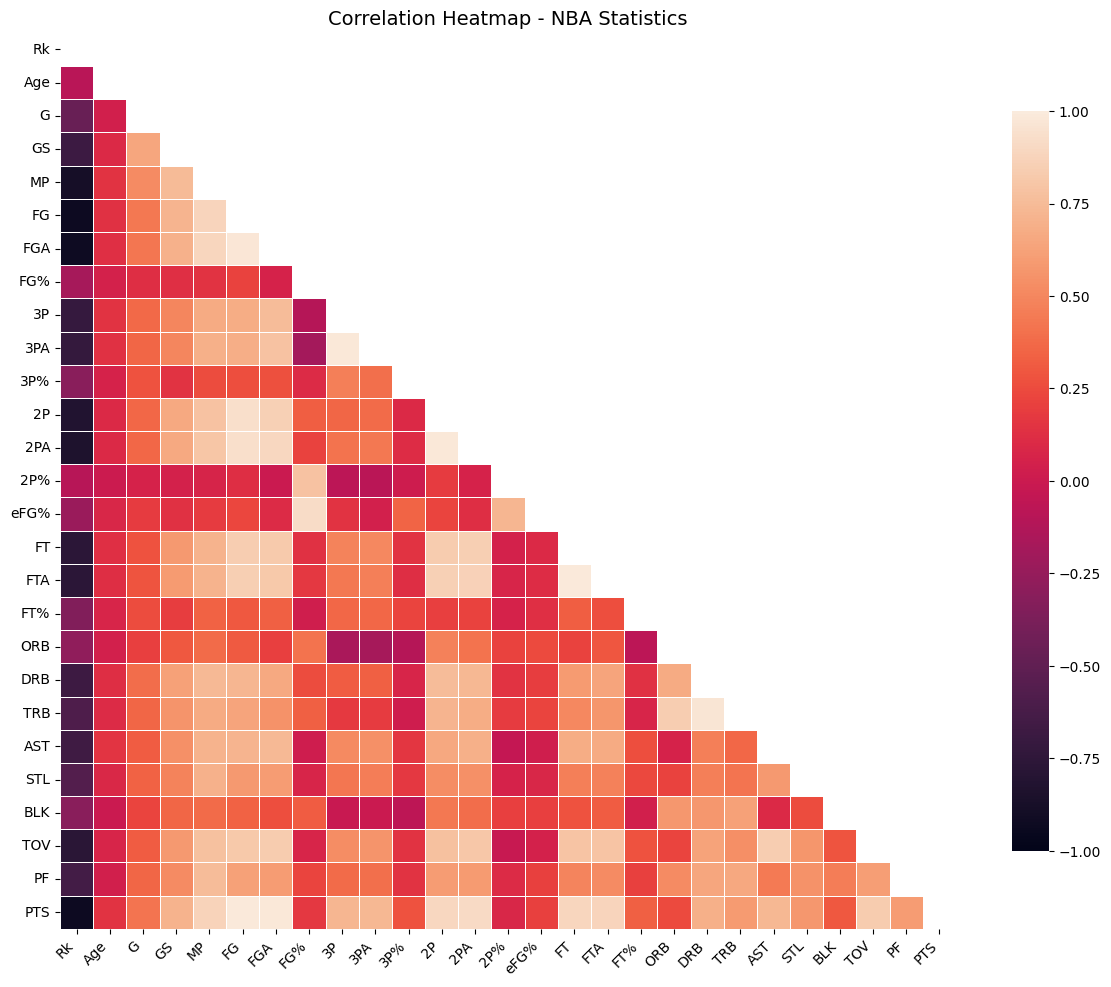

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve HTML table data
url = 'https://www.basketball-reference.com/leagues/NBA_2026_per_game.html'
html = pd.read_html(url, header=0)
df2026 = html[0]

# Remove any rows that do not have a valid numeric value for age
raw_df = df2026.drop(df2026[df2026.Age == 'Age'].index)

# Replace missing values with 0
clean_df = raw_df.fillna(0)

# Export dataframe as a CSV file
clean_df.to_csv('nba2026.csv', index=False)

# Read CSV data file back as your primary working dataframe
imported_df = pd.read_csv('nba2026.csv')

# Pre-convert metrics to clear numeric formats to avoid data errors
numeric_cols = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
                '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB',
                'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

for col in numeric_cols:
    if col in imported_df.columns:
        imported_df[col] = pd.to_numeric(imported_df[col], errors='coerce').fillna(0)

print("Data successfully loaded and cleaned! Dimensions:", imported_df.shape)
print("-" * 50)

# Question 1 Code
imported_df.columns = imported_df.columns.str.strip()
imported_df.rename(columns={'Team': 'Tm', 'TEAM': 'Tm'}, inplace=True)
imported_df['PTS'] = pd.to_numeric(imported_df['PTS'], errors='coerce')
highest_scorer = imported_df[imported_df['PTS'] == imported_df['PTS'].max()]

print("\n--- QUESTION 1 OUTPUT ---")
display(highest_scorer[['Player', 'Tm', 'PTS']])

# Question 2 Code
print("\n--- QUESTION 2 OUTPUT ---")
display(highest_scorer[['Player', 'Pos', 'PTS']])

# Question 3 Code
print("\n--- QUESTION 3 OUTPUT ---")
display(highest_scorer[['Player', 'G', 'PTS']])

# Question 4 Code
print("\n--- QUESTION 4 OUTPUT ---")
top_assists_player = imported_df[imported_df['AST'] == imported_df['AST'].max()]
display(top_assists_player[['Player', 'Tm', 'AST']])

# Question 5 Code
print("\n--- QUESTION 5 OUTPUT ---")
elite_scorers = imported_df[imported_df['PTS'] > 25]
print(f"Total number of players scoring > 25 PTS: {len(elite_scorers)}")

# Question 6 Code
print("\n--- QUESTION 6 OUTPUT ---")
df_numerical = imported_df.select_dtypes(include='number')
corr_matrix = df_numerical.corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="rocket", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - NBA Statistics", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()